In [ ]:
from download_tools import *
import matplotlib.pyplot as plt
import numpy as np
from normalizer import RiverStageNormalizer


In [24]:
def trim_and_interpolate(arr):
    # Find indices of valid (non-NaN) values
    valid = np.where(~np.isnan(arr))[0]
    
    if len(valid) == 0:
        return arr  # all NaN, nothing to do
    
    # Trim to the range between first and last valid values
    first, last = valid[0], valid[-1]
    trimmed = arr[first:last + 1]
    
    # Interpolate the interior NaNs
    nans = np.isnan(trimmed)
    x = np.arange(len(trimmed))
    trimmed[nans] = np.interp(x[nans], x[~nans], trimmed[~nans])
    
    return trimmed

In [ ]:

# Southeast (NC, SC, GA, VA, FL, AL)
sites_southeast = [
    "02177000", "02178400", "03455500", "03500000", "02143500",
    "02087500", "02089500", "02091500", "02096500", "02102000",
]

sites = sites_southeast

start_date = "2005-01-01"
end_date = "2026-01-01"
dt = 15

y_col = '00065'  # Depth
target_folder = 'data'
results = {}

for site_id in sites:
    site_df = load_site(site_id, target_folder, start_date, end_date, download=True)
    data_series = site_df[y_col].astype(float)
    data_npy = data_series.to_numpy()

    try:
        normalizer = RiverStageNormalizer(return_period_years=5).fit(data_npy)
        y_norm = normalizer.transform(data_npy)
        print(f"[{site_id}] {normalizer.summary()}")
    except ValueError as e:
        print(f"[{site_id}] normalization failed: {e}")
        normalizer = None
        y_norm = None

    results[site_id] = {
        "y": data_npy,
        "y_norm": y_norm,
        "normalizer": normalizer,
    }


loading site 02177000
loaded data for site 02177000
loading site 02178400


c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:46: DtypeWarning: Columns (3,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True, dtype={'00065': 'float32'})


loaded data for site 02178400
loading site 03455500


c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:46: DtypeWarning: Columns (3,7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True, dtype={'00065': 'float32'})


loaded data for site 03455500
loading site 03500000


...

loaded data for site 02143500
loading site 02087500


c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:46: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True, dtype={'00065': 'float32'})


loaded data for site 02087500
loading site 02089500
loaded data for site 02089500
loading site 02091500
loaded data for site 02091500
loading site 02096500


c:\Users\hmont\Documents\Duke\Calculus of Sustainability\Project\SDE_Stage\SDE_Analysis\download_tools.py:46: DtypeWarning: Columns (3,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0, parse_dates=True, dtype={'00065': 'float32'})


loaded data for site 02096500
loading site 02102000
loaded data for site 02102000


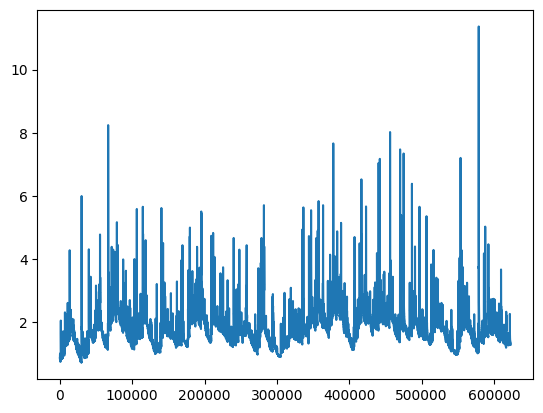

In [26]:
y = results["02177000"]
y_clean = trim_and_interpolate(y)
plt.plot(y_clean, label='Cleaned')